In [1]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import pickle

run_idx = 34
with open(f"../stats/spe_solver_space_scheme_run_{run_idx}.pkl", "rb") as f:
    solver_space_scheme = pickle.load(f)

# Load permutations
with open(f"../stats/spe_permutations_{run_idx}.pkl", "rb") as f:
    permutations = pickle.load(f)
    permutations_x = permutations['x']
    permutations_z = permutations['z']


solver_space_scheme

{'block_type': 'PetscKSPScheme',
 'petsc_options': {'ksp_monitor': None,
  'ksp_rtol': 1e-12,
  'ksp_gmres_restart': NumericalChoices(ksp_gmres_restart: [10 30 50])},
 'compute_eigenvalues': False,
 'preconditioner': {'block_type': CategoricalChoices([{'block_type': 'PetscFieldSplitScheme', 'groups': [0, 1], 'python_pc': {'block_type': 'PcPythonPermutation', 'permutation_type': 'pt_permutation', 'p_groups': [0], 't_groups': [1], 'block_size': 2}, 'elim_options': CategoricalChoices([{'python_pc_type': 'ilu', 'python_pc_factor_levels': NumericalChoices(python_pc_factor_levels: [0 1 2])}, {'python_pc_type': 'sor'}, {'python_pc_type': 'pbjacobi'}, {'python_pc_type': 'hypre', 'python_pc_hypre_type': 'boomeramg', 'python_pc_hypre_boomeramg_strong_threshold': NumericalChoices(python_pc_hypre_boomeramg_strong_threshold: [0.5 0.7 0.9]), 'python_pc_hypre_boomeramg_P_max': 16, 'python_pc_hypre_boomeramg_agg_nl': NumericalChoices(python_pc_hypre_boomeramg_agg_nl: [0 1 2]), 'python_pc_hypre_boomera

In [3]:
solver_space = SolverSpace(
    solver_space_scheme=solver_space_scheme,
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = len(solver_space.all_decisions_encoding)
print(solver_space.decision_tree)
print("Num solvers:", num_solvers)

performance_predictor = PerformancePredictorPassiveAgressive(
    num_solvers=num_solvers,
)
solver_selector = SolverSelector(
    # reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)

block_type: PetscKSPScheme
| ksp_gmres_restart: Choices from 10 to 50, len = 3
| block_type (fork with 2 branches):
| | block_type: PetscFieldSplitScheme
| | | elim_options (fork with 4 branches):
| | | | python_pc_type: ilu
| | | | | python_pc_factor_levels: Choices from 0 to 2, len = 3
| | | | python_pc_type: sor
| | | | python_pc_type: pbjacobi
| | | | python_pc_type: hypre
| | | | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | | | python_pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | | | python_pc_hypre_boomeramg_relax_type_all (fork with 4 branches):
| | | | | | symmetric-SOR/Jacobi
| | | | | | l1scaled-Jacobi
| | | | | | SOR/Jacobi
| | | | | | Jacobi
| | block_type: PetscCompositeScheme
| | | pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | pc_hypre_boomeramg_relax_type_all (fork with 4 branches):
| | | | symmetric-SOR/Jacobi
| | | | l1scal

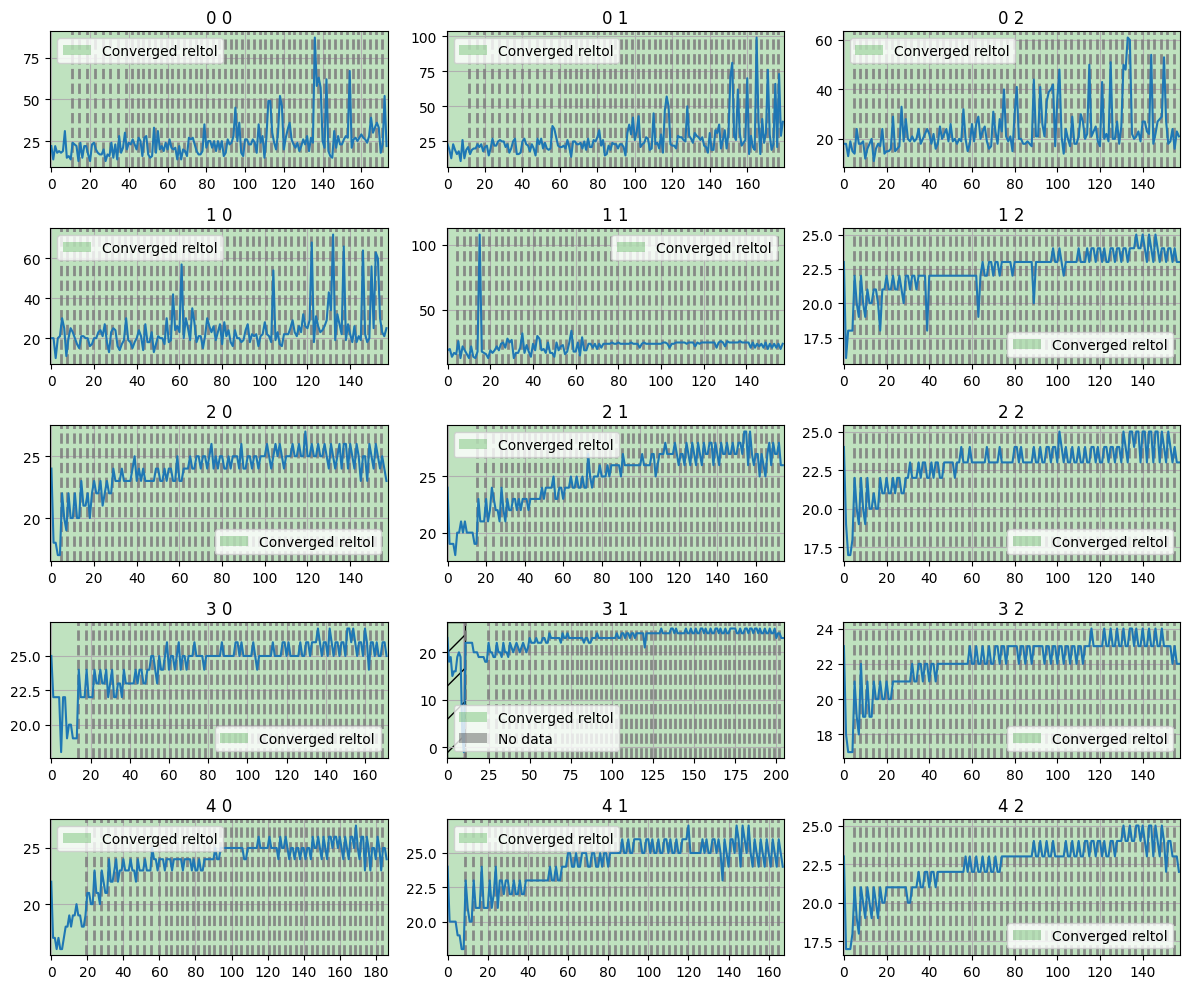

In [4]:
from itertools import count
from copy import copy
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
    get_linear_solve_time
)
from solver_selection_thm.spe_physics import X_SLICES, Z_SLICES, simulation_name, params


data_simulations = []
solver_selection_history = []

Z_SLICES = np.array(Z_SLICES)
X_SLICES = np.array(X_SLICES)


counter = 0
for z_slice in Z_SLICES[permutations_z]:
    data_row = []
    data_simulations.append(data_row)
    for x_slice in X_SLICES[permutations_x]:
        # counter += 1
        # if counter <= 13:
        #     data_row.append(None)
        #     continue
        params["x_slice"] = x_slice
        params["z_slice"] = z_slice
        sim_name = f"run_{run_idx}_{simulation_name(params)}"
        try:
            data = load_data(f"../stats/{sim_name}.json")
            solver_selector.history.load(f"../stats/solver_selection_history_{sim_name}.npy")
            solver_selection_history.append(copy(solver_selector.history))
            data_row.append(data)
        except FileNotFoundError:
            print('failed to load', sim_name)
            solver_selection_history.append(None)
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(Z_SLICES), ncols=len(X_SLICES), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data, legend=True)
        color_time_steps(data)
        plt.legend()

        ax.plot(get_gmres_iterations(data))
        # ax.set_yscale('log')
        # print(inlet_placement, outlet_placement)
        ax.set_title(f"{i} {j}")

plt.tight_layout()

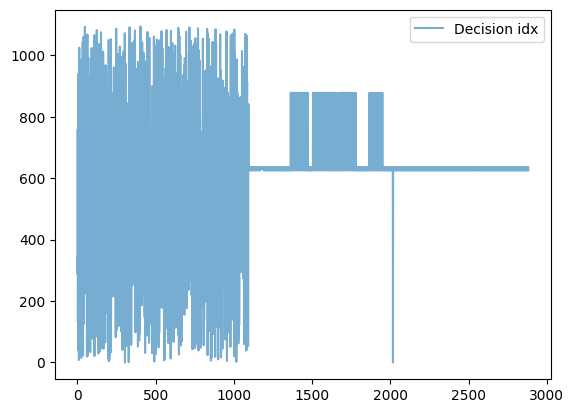

In [5]:
from solver_selection_thm.selector import SolverSelectorHistory
common_history: SolverSelectorHistory = solver_selection_history[-1]
for x in solver_selection_history:
    if x is None:
        continue
    common_history = x



decision_id = np.array(common_history.decision_idx)

# plt.plot(common_history.expectation, label='Expectation', alpha=0.6)
# plt.plot(common_history.reward, label='Reward', alpha=0.6)
plt.plot(common_history.decision_idx, label='Decision idx', alpha=0.6)

plt.legend()
# plt.ylim(-2, 0)

In [6]:
print(len(common_history.reward))
print(len(common_history.features))
print(np.unique(decision_id).size, num_solvers)


2883
2883
1095 1095


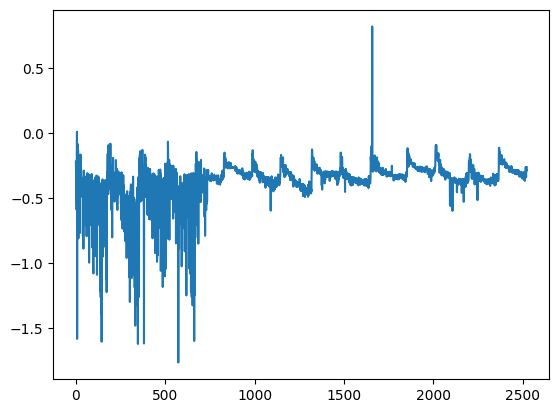

In [7]:
X, y = np.array(common_history.features), np.array(common_history.reward)

FAIL_REWARD = -100
plt.plot(y[y > FAIL_REWARD])

success = y > FAIL_REWARD

## Can we classify to failed/not failed?

(array([ 359., 2524.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

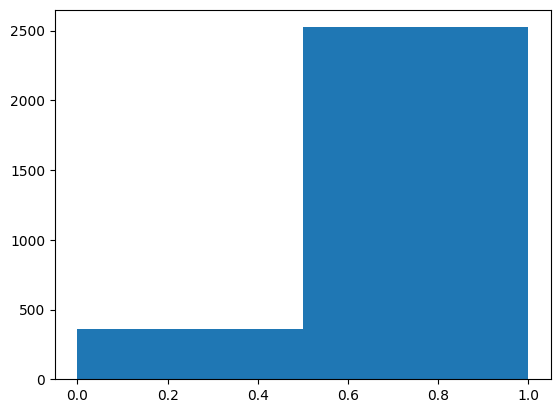

In [8]:
ycat = success[:]
plt.hist(ycat.astype(int), bins=2)

In [9]:
from solver_selection_thm.solver_space import explain_decision

features_explained = [
    "dt",
    "temp_min",
    "temp_max",
    "cfl",
    "enthalpy_max",
    "enthalpy_mean",
    "fourier_max",
    "fourier_mean",
    "perm_estimate",
    'solver_reused',

] + [explain_decision(solver_space, i) for i in range(26)]

<BarContainer object of 36 artists>

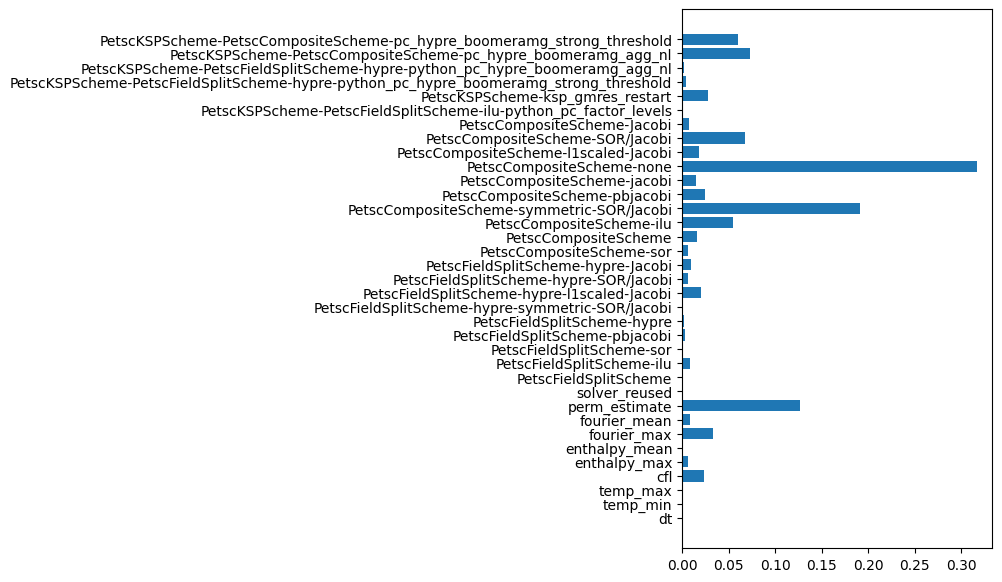

In [10]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(X), ycat, n_neighbors=10, random_state=42
)
plt.figure(figsize=(4, 7))
plt.barh(features_explained, mi)

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

cv_results = cross_validate(
    classifier,
    X,
    ycat,
    cv=5,
    scoring="average_precision",
    return_train_score=True,
    return_estimator=True,
)
print("Train scores:", cv_results["train_score"])
print("Test scores:", cv_results["test_score"])
print("Mean Train:", np.mean(cv_results["train_score"]))
print("Mean Test:", np.mean(cv_results["test_score"]))

best_classifier_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_classifier_offline

Train scores: [0.99994063 1.         0.99994369 0.99979936 0.9999433 ]
Test scores: [1.         0.98858838 1.         0.99925466 1.        ]
Mean Train: 0.9999253941177324
Mean Test: 0.9975686070981158


SuccessClassifier()

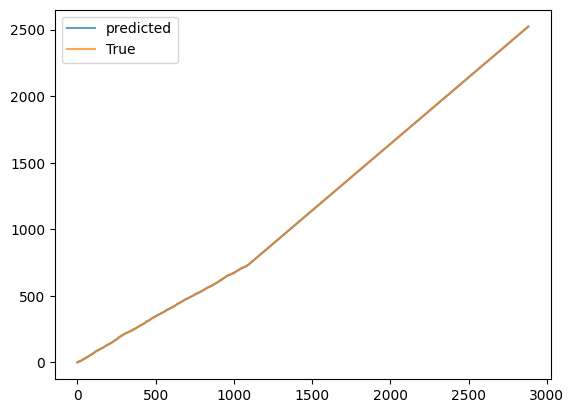

In [12]:
plt.plot(np.cumsum(best_classifier_offline.predict(X)), label='predicted', alpha=0.7)
# plt.plot(search.best_estimator_.predict(Xsuccess), label='predicted', alpha=0.7)
plt.plot(np.cumsum(ycat), label='True', alpha=0.7)
# plt.xlim(200, 400)
# plt.ylim(-2.5, 0)
plt.legend()

In [13]:
# import math


# class OnlineClassifier(ClassifierMixin, BaseEstimator):

#     def __init__(self, Xoffline, yoffline):
#         self.classes_ = np.array([False, True])
#         self.Xoffline = Xoffline
#         self.yoffline = yoffline
#         self.classifier = SuccessClassifier()
#         self.classifier.fit(Xoffline, yoffline)
#         self.window_size = 1

#     def fit(self, X, y):
#         for i in range(math.ceil(X.shape[0] / self.window_size)):
#             start = i * self.window_size
#             end = start + self.window_size
#             Xbatch, ybatch = X[start:end], y[start:end]
#             self.classifier.partial_fit(Xbatch, ybatch)
#         return self

#     def predict(self, X):
#         return self.classifier.predict(X)

#     def predict_proba(self, X):
#         return self.classifier.predict_proba((X))

#     def decision_function(self, X):
#         return self.classifier.decision_function((X))


# sep = num_solvers
# Xoffline, ycat_offline = X[:sep], ycat[:sep]
# Xonline, ycat_online = X[sep:], ycat[sep:]

# online_classifier = OnlineClassifier(Xoffline, ycat_offline)

# cv_results = cross_validate(
#     online_classifier,
#     Xonline,
#     ycat_online,
#     cv=5,
#     scoring="average_precision",
#     return_train_score=True,
#     return_estimator=True,
#     n_jobs=1
# )
# print("Train scores:", cv_results["train_score"])
# print("Test scores:", cv_results["test_score"])
# print("Mean Train:", np.mean(cv_results["train_score"]))
# print("Mean Test:", np.mean(cv_results["test_score"]))

Split to xsuccess and xfail

In [14]:
Xsuccess = X[success]
ysuccess = y[success]

# In offline setting, how well does the data describe the target?
1. Estimating Mutual Information (MI)


<BarContainer object of 36 artists>

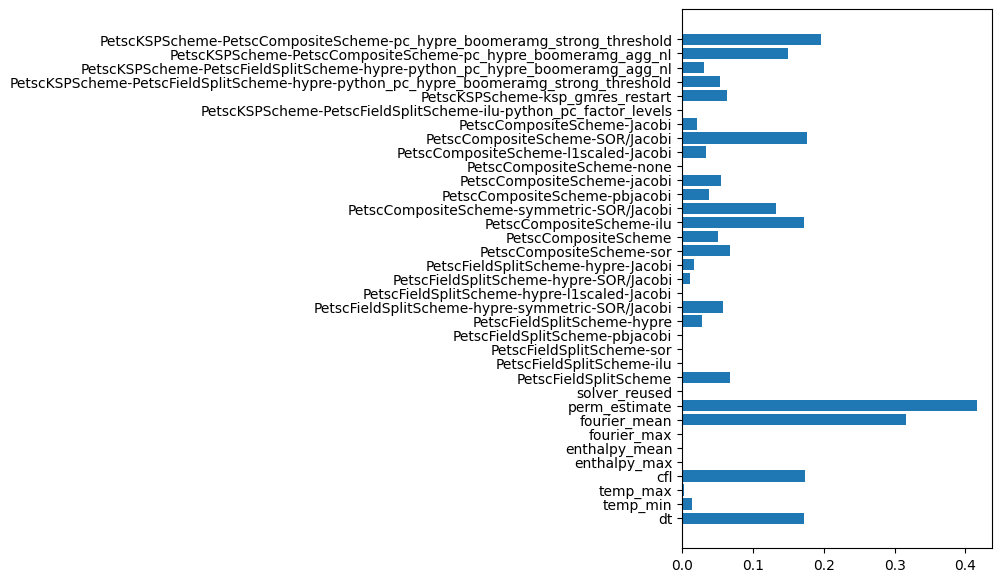

In [15]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(Xsuccess), ysuccess, n_neighbors=10, random_state=42
)
plt.figure(figsize=(4, 7))
plt.barh(features_explained, mi)

2. Training offline model with cross-validation and comparing its

In [16]:
# Xsuccess = Xsuccess.clip(-1e10, 1e10)

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from solver_selection_thm.performance_predictor import RewardRegressor
from sklearn.base import RegressorMixin
from sklearn.ensemble import RandomForestRegressor



# offline_pipeline = RewardRegressor()
# offline_pipeline = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
offline_pipeline = make_pipeline(StandardScaler(), RandomForestRegressor(criterion='squared_error', random_state=42))

scoring = 'r2'
# scoring = 'neg_median_absolute_error'
# scoring = 'neg_mean_absolute_error'
# scoring = 'explained_variance'
cv_results = cross_validate(offline_pipeline, Xsuccess.clip(-1e10, 1e10), ysuccess, cv=4, scoring=scoring, return_train_score=True, return_estimator=True)
# cv_results = cross_validate(search.best_estimator_, Xsuccess, ysuccess, cv=5, scoring=scoring, return_train_score=True, return_estimator=True)


# Output
print("Train R² scores:", cv_results["train_score"])
print("Test R² scores:", cv_results["test_score"])
print("Mean Train R²:", np.mean(cv_results["train_score"]))
print("Mean Test R²:", np.mean(cv_results["test_score"]))

best_regressor_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_regressor_offline

Train R² scores: [0.94954998 0.97570649 0.98946372 0.98030582]
Test R² scores: [ 0.67487219  0.88146911 -0.05138298  0.6376684 ]
Mean Train R²: 0.9737565022500365
Mean Test R²: 0.5356566822448509


,steps,"[('standardscaler', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


Tuning offline model

In [18]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'mlpregressor__hidden_layer_sizes': [(10,), (30,), (30, 30)],
#     'mlpregressor__alpha': [1e-5, 1e-4, 1e-3],
#     'mlpregressor__learning_rate_init': [1e-3, 1e-2],
#     'mlpregressor__activation': ['relu', 'tanh'],
#     'mlpregressor__solver': ['adam', 'lbfgs'],  # 'lbfgs' ignores early_stopping
# }


# offline_pipeline = make_pipeline(
#     StandardScaler(),
#     MLPRegressor()
# )

# search = GridSearchCV(
#     offline_pipeline,
#     param_grid=param_grid,
#     scoring="neg_mean_absolute_error",
#     n_jobs=6,
#     cv=5,
#     verbose=1,
# )

# search.fit(Xsuccess, ysuccess)

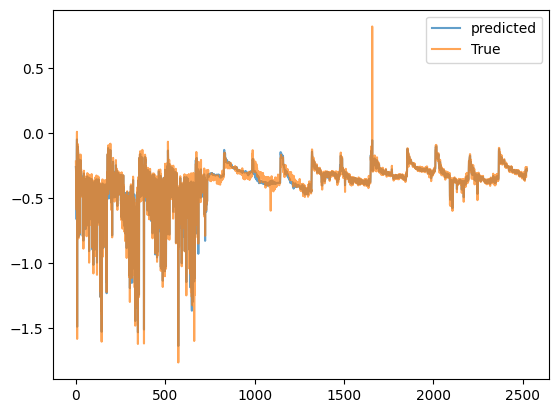

In [20]:
plt.plot(best_regressor_offline.predict(Xsuccess.clip(-1e10, 1e10)), label='predicted', alpha=0.7)
# plt.plot(search.best_estimator_.predict(Xsuccess), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
# plt.xlim(200, 400)
# plt.ylim(-2.5, 0)
plt.legend()

3. Cross-validation R2 score of the online model

In [82]:
# from sklearn.base import BaseEstimator, RegressorMixin
# import math

# sep = np.sum(success[:num_solvers])
# Xoffline, yoffline = Xsuccess[:sep], ysuccess[:sep]
# Xonline, yonline = Xsuccess[sep:], ysuccess[sep:]


# class OnlineRegressor(BaseEstimator, RegressorMixin):
#     def __init__(self):
#         self.regressor = RewardRegressor()
#         self.window_size = 1

#     def fit(self, X, y):
#         global Xoffline
#         global yoffline
#         self.regressor.fit(Xoffline, yoffline)
#         for i in range(math.ceil(X.shape[0] / self.window_size)):
#             start = i * self.window_size
#             end = start + self.window_size
#             Xbatch, ybatch = X[start:end], y[start:end]
#             self.regressor.partial_fit(Xbatch, ybatch)

#     def predict(self, X):
#         return self.regressor.predict(X)
    
#     def score(self, X, y, sample_weight=None):
#         assert False, "why are you called?"
#         # print("Scoring with", X.shape)
#         # return -mean_absolute_error(y, self.predict(X), sample_weight=sample_weight)

    
# # scoring = 'r2'
# # scoring = 'neg_median_absolute_error'
# scoring = 'neg_mean_absolute_error'
# # scoring = 'explained_variance'

# online_regressor = OnlineRegressor()
# cv_results_online = cross_validate(online_regressor, Xonline, yonline, cv=5, scoring=scoring, return_train_score=True, return_estimator=True, error_score='raise')

# # Output
# print("Train R² scores:", cv_results_online["train_score"])
# print("Test R² scores:", cv_results_online["test_score"])
# print("Mean Train R²:", np.mean(cv_results_online["train_score"]))
# print("Mean Test R²:", np.mean(cv_results_online["test_score"]))

# best_regressor_online = cv_results_online['estimator'][np.argmax(cv_results_online['test_score'])]
# best_regressor_online


Ranking metrics for our regression model

Trying to optimize macroparam for online MLP

In [83]:
# from sklearn.base import BaseEstimator
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_absolute_error
# from sklearn.model_selection import GridSearchCV

# sep = np.sum(success[:num_solvers])
# Xoffline, yoffline = Xsuccess[:sep], ysuccess[:sep]
# Xonline, yonline = Xsuccess[sep:], ysuccess[sep:]


# class PipelineWrapper(BaseEstimator):
#     def __init__(
#         self,
#         hidden_layer_sizes=(100,),
#         alpha=0.0001,
#         learning_rate_init=0.001,
#         activation="relu",
#         solver="adam",
#         learning_rate="invscaling",
#     ):
#         self.hidden_layer_sizes = hidden_layer_sizes
#         self.alpha = alpha
#         self.activation = activation
#         self.learning_rate_init = learning_rate_init
#         self.solver = solver
#         self.learning_rate = learning_rate
#         self.scaler = StandardScaler()
#         self.mlp = MLPRegressor(
#             hidden_layer_sizes=self.hidden_layer_sizes,
#             alpha=self.alpha,
#             learning_rate_init=learning_rate_init,
#             learning_rate=learning_rate,
#             max_iter=500,
#             random_state=42,
#             activation=activation,
#             solver=solver,
#         )
#         self.window_size = 2000

#     # def __init__(
#     #     self,
#     #     loss="squared_error",
#     #     penalty="l2",
#     #     alpha=0.0001,
#     #     l1_ratio=0.15,
#     #     fit_intercept=True,
#     #     max_iter=1000,
#     #     tol=1e-3,
#     #     shuffle=True,
#     #     verbose=0,
#     #     epsilon=0.01,
#     #     random_state=None,
#     #     learning_rate="invscaling",
#     #     eta0=0.01,
#     #     power_t=0.25,
#     #     early_stopping=False,
#     #     validation_fraction=0.1,
#     #     n_iter_no_change=5,
#     #     warm_start=False,
#     #     average=False,
#     # ):
#     #     self.loss = loss
#     #     self.penalty = penalty
#     #     self.alpha = alpha
#     #     self.l1_ratio = l1_ratio
#     #     self.fit_intercept = fit_intercept
#     #     self.max_iter = max_iter
#     #     self.tol = tol
#     #     self.shuffle = shuffle
#     #     self.verbose = verbose
#     #     self.epsilon = epsilon
#     #     self.random_state = random_state
#     #     self.learning_rate = learning_rate
#     #     self.eta0 = eta0
#     #     self.power_t = power_t
#     #     self.early_stopping = early_stopping
#     #     self.validation_fraction = validation_fraction
#     #     self.n_iter_no_change = n_iter_no_change
#     #     self.warm_start = warm_start
#     #     self.average = average

#     #     self.scaler = StandardScaler()
#     #     self.mlp = SGDRegressor(
#     #         loss=self.loss,
#     #         penalty=self.penalty,
#     #         alpha=self.alpha,
#     #         l1_ratio=self.l1_ratio,
#     #         fit_intercept=self.fit_intercept,
#     #         max_iter=self.max_iter,
#     #         tol=self.tol,
#     #         shuffle=self.shuffle,
#     #         verbose=self.verbose,
#     #         epsilon=self.epsilon,
#     #         random_state=self.random_state,
#     #         learning_rate=self.learning_rate,
#     #         eta0=self.eta0,
#     #         power_t=self.power_t,
#     #         early_stopping=self.early_stopping,
#     #         validation_fraction=self.validation_fraction,
#     #         n_iter_no_change=self.n_iter_no_change,
#     #         warm_start=self.warm_start,
#     #         average=self.average,
#     #     )
#     #     self.window_size = 10

#     def fit(self, X, y):
#         global Xoffline
#         global yoffline
#         self.mlp.fit(self.scaler.fit_transform(Xoffline), yoffline)
#         # print("Fitting with", X.shape)
#         for i in range(math.ceil(X.shape[0] / self.window_size)):
#             start = i * self.window_size
#             end = start + self.window_size
#             Xbatch, ybatch = X[start:end], y[start:end]
#             self.scaler.partial_fit(Xbatch)
#             self.mlp.partial_fit(self.scaler.transform(Xbatch), ybatch)
#         return self

#     def predict(self, X):
#         return self.mlp.predict(self.scaler.transform(X))

#     def score(self, X, y):
#         print("Scoring with", X.shape)
#         return -mean_absolute_error(y, self.predict(X))


# param_grid = {
#     "hidden_layer_sizes": [(10,), (30,), (10, 10), (30, 30)],
#     "alpha": [1e-5, 1e-4, 1e-3],
#     "learning_rate_init": [1e-3, 1e-2],
#     "learning_rate": ["constant", "invscaling", "adaptive"],
#     "activation": ["relu", "tanh"],
#     "solver": ["adam", "lbfgs", "sgd"],  # 'lbfgs' ignores early_stopping
# }
# # param_grid = {
# #     "loss": ["squared_error", "huber", "epsilon_insensitive"],
# #     "penalty": ["l2", "l1", "elasticnet"],
# #     "alpha": [1e-4, 1e-3, 1e-2],
# #     "learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
# #     "eta0": [0.001, 0.01, 0.1],  # initial learning rate
# #     "max_iter": [1000],  # fixed for speed
# #     "tol": [1e-3],  # fixed for simplicity
# #     "early_stopping": [True, False],
# # }

# model = PipelineWrapper()
# grid = GridSearchCV(
#     model,
#     param_grid,
#     scoring="r2",
#     n_jobs=6,
#     cv=5,
#     verbose=1,
# )

# grid.fit(Xsuccess, ysuccess)

In [84]:
# plt.plot(best_regressor_online.predict(Xsuccess), label='predicted', alpha=0.6)
# # plt.plot(grid.best_estimator_.predict(Xsuccess), label='predicted', alpha=0.6)
# plt.plot(ysuccess, label='True', alpha=0.6)
# plt.legend()

4. Now we treat them as classifiers. Offline - ground truth. How often does Online make different decisions? How much does this cost to it?

In [21]:
sep = num_solvers
Xoffline, yoffline = X[:sep], y[:sep]
Xonline, yonline = X[sep:], y[sep:]
print(Xoffline.shape, yoffline.shape, Xonline.shape, yonline.shape)

(1095, 36) (1095,) (1788, 36) (1788,)


In [ ]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

Definig scores for ranking problem

In [23]:
from scipy.stats import spearmanr
import warnings
from scipy.stats import ConstantInputWarning

# warnings.filterwarnings("ignore", category=ConstantInputWarning)

def top1_score(ypred, ytrue):
    return np.argmax(ypred) == np.argmax(ytrue)

def topk_score(ypred, ytrue):
    top_k = 10
    return int(np.argmax(ytrue) in np.argsort(ypred)[-top_k:])

def rank_true_max(ypred, ytrue):
    rank = (-ypred).argsort().tolist().index(np.argmax(ytrue)) + 1
    return rank

def rank_spearman(ypred, ytrue):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConstantInputWarning)
        corr = spearmanr(ypred, ytrue).correlation
    if np.isnan(corr):
        # happens for constant array
        return 1.
    return corr

In [54]:
from sklearn.neighbors import KNeighborsRegressor

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


best_regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=RandomForestRegressor(criterion='squared_error', random_state=42))
# best_regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=KNeighborsRegressor())
best_regressor_offline.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape

regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
regressor_online.fit(Xoffline, yoffline)

decisions_online = []
decisions_offline = []
reward_offline = []
reward_online = []
reward_feedback = []
scores_top1 = []
scores_topk = []
scores_rank_true_max = []
scores_spearman = []
pred_online_list = []
pred_offline_list = []

for Xfeature in Xonline_features[:]:
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    max_score_online = predictions_online[max_score_idx_online]

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))
    max_score_idx_offline = np.argmax(predictions_offline)
    max_score_offline = predictions_offline[max_score_idx_offline]

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    regressor_online.partial_fit(X_feedback, [y_feedback])

    # saving stats
    decisions_offline.append(max_score_idx_offline)
    decisions_online.append(max_score_idx_online)
    reward_feedback.append(y_feedback)
    reward_offline.append(max_score_offline)
    reward_online.append(max_score_online)
    top1_score_ = top1_score(ypred=predictions_online, ytrue=predictions_offline)
    scores_top1.append(top1_score_)
    scores_topk.append(topk_score(ypred=predictions_online, ytrue=predictions_offline))
    rank_true_max_ = rank_true_max(ypred=predictions_online, ytrue=predictions_offline)
    scores_rank_true_max.append(rank_true_max_)
    rank_spearman_ = rank_spearman(ypred=predictions_online, ytrue=predictions_offline)
    scores_spearman.append(rank_spearman_)
    pred_offline_list.append(predictions_offline)
    pred_online_list.append(predictions_online)

2524 2883
736 1095


Metrics to evaluate the model:
- (maximize) mean spearman score
- (minimize) mean rank_true_max
- (minimize) num failures when expected success
- (minimize) for successful iterations, oracle reward for online decision minus oracle best reward (regret)
- (minimize) time for partial fit and evaluate (todo)

Mean Spearman score: 0.6943148989697082


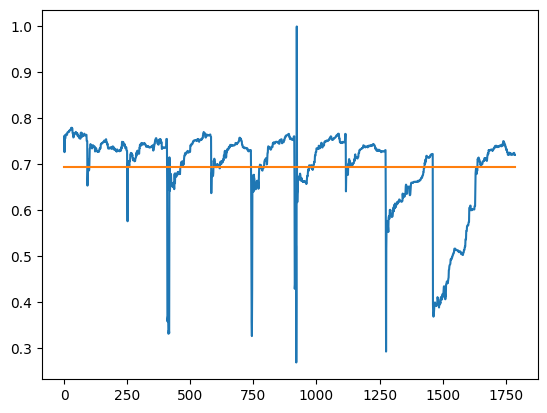

In [55]:
plt.plot(scores_spearman)
mean = np.mean(scores_spearman)
plt.plot([0, len(scores_rank_true_max)], [mean,mean])
print('Mean Spearman score:', mean)

Mean rank true max: 229.41051454138702


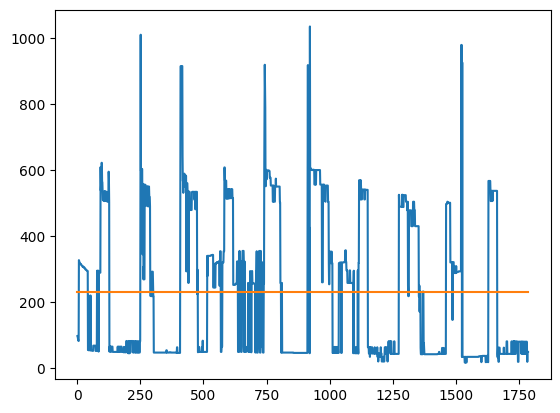

In [56]:
plt.plot(np.array(scores_rank_true_max))
mean = np.mean(scores_rank_true_max)
plt.plot([0, len(scores_rank_true_max)], [mean,mean])
print("Mean rank true max:", mean)

Num failures when expected success: 0


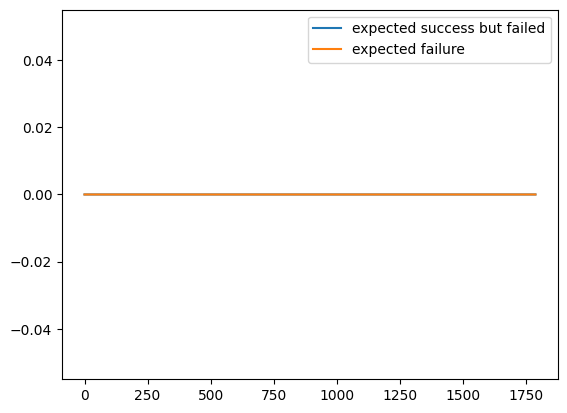

In [57]:
expected_success = np.array(reward_online) > FAIL_REWARD
feedback_success = np.array(reward_feedback) > FAIL_REWARD
expected_success_but_failed = expected_success * np.logical_not(feedback_success)
plt.plot(np.cumsum(expected_success_but_failed), label='expected success but failed')
plt.plot(np.cumsum(np.logical_not(expected_success)), label='expected failure')
plt.legend()
print("Num failures when expected success:", np.sum(expected_success_but_failed))

Regret: -33.221932090352


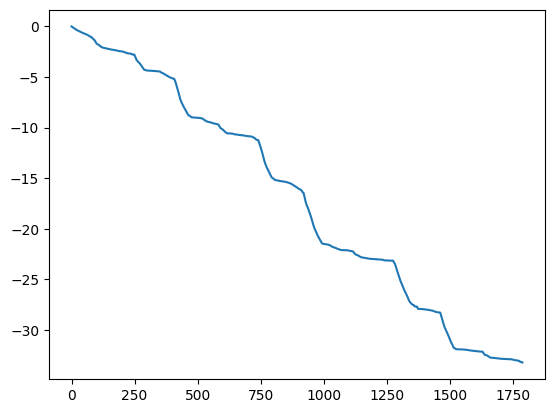

In [58]:
regret = np.subtract(reward_feedback, reward_offline)[feedback_success]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

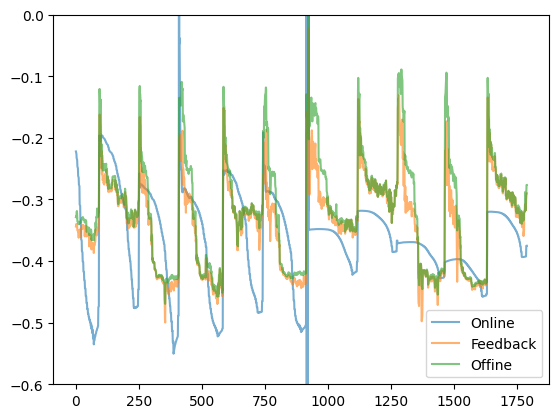

In [59]:
plt.plot(reward_online, label='Online', alpha=0.6)
plt.plot(reward_feedback, label='Feedback', alpha=0.6)
plt.plot(reward_offline, label='Offine', alpha=0.6)
plt.ylim(-0.6, 0)
plt.legend()

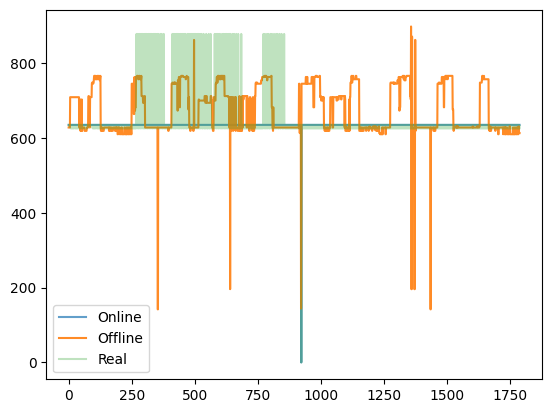

In [60]:
plt.plot(decisions_online, label='Online', alpha=0.7)
plt.plot(decisions_offline, label='Offline', alpha=0.9)
plt.plot(common_history.decision_idx[sep:], label='Real', alpha=0.3)
plt.legend()

<BarContainer object of 29 artists>

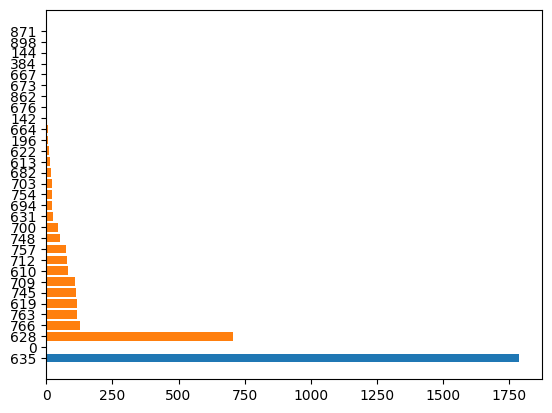

In [61]:
def count_decision_frequency(decisions, threshold=0):
    num_seleced = np.zeros(num_solvers)
    np.add.at(num_seleced, decisions, 1)
    frequent_solver_idx = np.argsort(num_seleced)[::-1]
    frequent_solver_idx = frequent_solver_idx[num_seleced[frequent_solver_idx] > threshold]
    return num_seleced, frequent_solver_idx

num_selected_offline, frequent_solver_idx_offline = count_decision_frequency(decisions_offline)
num_selected_online, frequent_solver_idx_online = count_decision_frequency(decisions_online)

plt.barh(frequent_solver_idx_online.astype(str), num_selected_online[frequent_solver_idx_online])
plt.barh(frequent_solver_idx_offline.astype(str), num_selected_offline[frequent_solver_idx_offline])

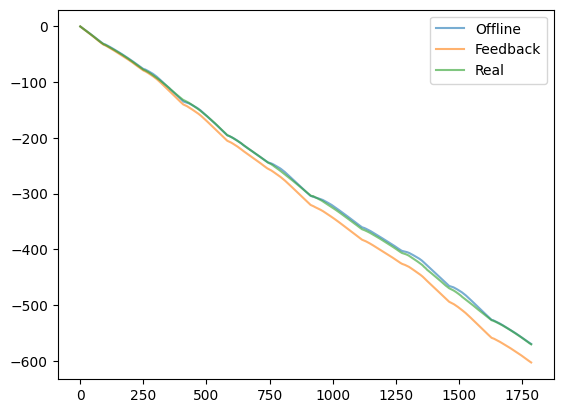

In [74]:
# plt.plot(np.cumsum(reward_online), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(reward_feedback), label='Feedback', alpha=0.6)
plt.plot(np.cumsum(common_history.reward[sep:]), label='Real', alpha=0.6)
plt.legend()

# How many times each solver was used?

array([897., 795.,  77.,  22.])

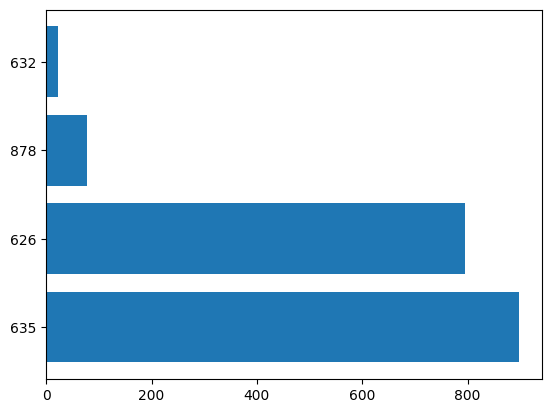

In [68]:
num_seleced, frequent_solver_idx = count_decision_frequency(common_history.decision_idx, threshold=2)

plt.barh(frequent_solver_idx.astype(str), num_seleced[frequent_solver_idx])
num_seleced[frequent_solver_idx]

/home/porepy/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/porepy/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


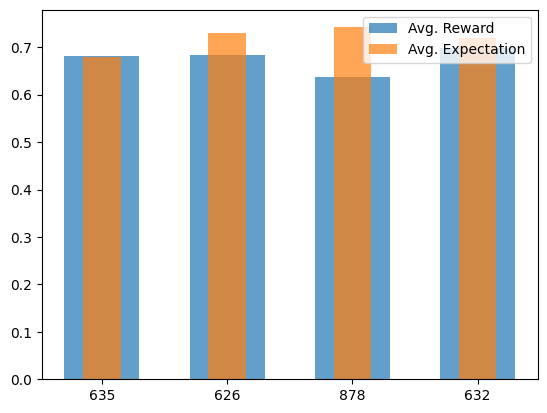

In [69]:
rewards_for_class = [[] for i in range(num_solvers)]
expectations_for_class = [[] for i in range(num_solvers)]


for reward, expectation, reward, solver_id in zip(y, common_history.expectation, common_history.reward, decision_id):
    if (-50 <= expectation <= 50 and -50 <= reward <= 50):
        rewards_for_class[solver_id].append(reward)
        expectations_for_class[solver_id].append(expectation)

avg_expectation_for_class = np.array([np.mean(x) for x in expectations_for_class])
avg_reward_for_class = np.array([np.mean(x) for x in rewards_for_class])

min_reward = -1
plt.bar(frequent_solver_idx.astype(str), avg_reward_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.6, label='Avg. Reward')
plt.bar(frequent_solver_idx.astype(str), avg_expectation_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.3, label='Avg. Expectation')
# plt.ylim(-2, 0.5)
plt.legend()

635, 626, 878

Transition matrix

In [70]:
from collections import defaultdict

category_to_idx = defaultdict(lambda: len(frequent_solver_idx)) | {x: i for i, x in enumerate(frequent_solver_idx)}
category_to_idx 

defaultdict(<function __main__.<lambda>()>, {635: 0, 626: 1, 878: 2, 632: 3})

In [71]:
M = np.zeros((frequent_solver_idx.size + 1, frequent_solver_idx.size + 1))
for a, b in zip(decision_id[:-1], decision_id[1:]):
    M[category_to_idx[a], category_to_idx[b]] += 1

P = M / M.sum(axis=1, keepdims=True)

Text(0.5, 1.0, 'P(next = (column) | current = (row))')

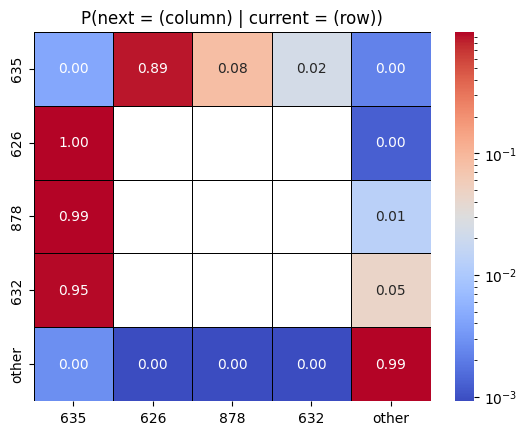

In [72]:
import seaborn as sns

labels = list(frequent_solver_idx.astype(str)) + ['other']

sns.heatmap(
    P,
    yticklabels=labels,
    xticklabels=labels,
    annot=True,
    fmt='.2f',
    norm="log",
    cmap="coolwarm",              # apply coolwarm palette
    linecolor="black",            # black grid lines
    linewidths=0.5                # line width > 0 to make lines visible
)
plt.title('P(next = (column) | current = (row))')

In [75]:
solver_space.config_from_decision(solver_space.all_decisions_encoding[635])

{'block_type': 'PetscKSPScheme',
 'petsc_options': {'ksp_monitor': None,
  'ksp_rtol': 1e-12,
  'ksp_gmres_restart': 50},
 'compute_eigenvalues': False,
 'preconditioner': {'block_type': 'PetscCompositeScheme',
  'groups': [0, 1],
  'solvers': {0: {'block_type': 'PetscFieldSplitScheme',
    'groups': [0],
    'fieldsplit_options': {'pc_fieldsplit_type': 'additive'},
    'elim_options': {'pc_type': 'hypre',
     'pc_hypre_type': 'boomeramg',
     'pc_hypre_boomeramg_strong_threshold': 0.9,
     'pc_hypre_boomeramg_agg_nl': 2,
     'pc_hypre_boomeramg_relax_type_all': 'SOR/Jacobi'},
    'complement': {'block_type': 'PetscFieldSplitScheme',
     'groups': [1],
     'elim_options': {'pc_type': 'sor'}}},
   1: {'block_type': 'PetscFieldSplitScheme',
    'groups': [0, 1],
    'python_pc': {'block_type': 'PcPythonPermutation',
     'permutation_type': 'pt_permutation',
     'p_groups': [0],
     't_groups': [1],
     'block_size': 2},
    'elim_options': {'python_pc_type': 'ilu'}}}}}

Assuming only one solver was allowed, what reward would we get if we chose system-AMG?

In [240]:
def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=RandomForestRegressor(criterion='squared_error', random_state=42))
regressor_offline.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape


reward_solvers = np.zeros((Xonline_features.shape[0], num_solvers))

for i, Xfeature in enumerate(Xonline_features[:]):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # offline
    predictions_offline = regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))
    reward_solvers[i] = predictions_offline
    

2524 2883


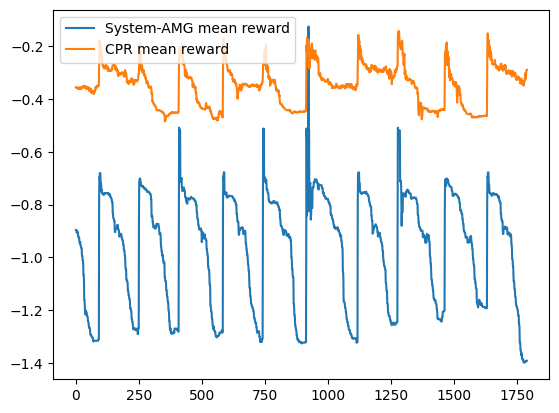

In [244]:
amg_rewards = reward_solvers[:, :123]
sorted_solver_ids = np.argsort(np.sum(amg_rewards,axis=0))[::-1][:110]  # 780
mean_amg_reward = np.mean(amg_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_amg_reward, label='System-AMG mean reward')

cpr_rewards = reward_solvers[:, 123:]
sorted_solver_ids = np.argsort(np.sum(cpr_rewards,axis=0))[::-1][:110]  # 780
mean_cpr_reward = np.mean(cpr_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_cpr_reward, label='CPR mean reward')

plt.legend()